## Denoising Diffusion Probabilistic Models

The theory, figures, and environment used here originate from the Diffusion Policy paper found [here](https://arxiv.org/pdf/2303.04137).

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Sequence, Dict, Union, Optional
import collections

from diffusers import DDPMScheduler, DDIMScheduler
from diffusers.training_utils import EMAModel
from diffusers.optimization import get_scheduler

#imports for environment
import pygame
import pymunk
import pymunk.pygame_util
from pymunk.space_debug_draw_options import SpaceDebugColor
from pymunk.vec2d import Vec2d
import shapely.geometry as sg
import gymnasium as gym
from gymnasium import spaces
import cv2
import skimage.transform as st
from skvideo.io import vwrite
from IPython.display import Video

import dill as pickle

# datasets and utilities
import os
import gdown
import zarr

from tqdm.auto import tqdm
import time
from abc import ABC, abstractmethod

torch.manual_seed(0)
np.random.seed(0)

[Diffusion Policy paper](https://arxiv.org/pdf/2303.04137)

![Diffusion Policy Diagram](diffusion_policy_diagram.png)

![Diffusion Policy Overview](diffusion_policy_overview.png)

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEBUG = False
print(f"Using device: {device}")

Using device: cuda


### **Environment**
Defines a PyMunk-based Push-T environment `PushTEnv`.

**Goal**: push the gray T-block into the green area.

Adapted from [Implicit Behavior Cloning](https://implicitbc.github.io/)

In [24]:
positive_y_is_up: bool = False
"""Make increasing values of y point upwards.

When True::

    y
    ^
    |      . (3, 3)
    |
    |   . (2, 2)
    |
    +------ > x

When False::

    +------ > x
    |
    |   . (2, 2)
    |
    |      . (3, 3)
    v
    y

"""

def to_pygame(p: Tuple[float, float], surface: pygame.Surface) -> Tuple[int, int]:
    """Convenience method to convert pymunk coordinates to pygame surface
    local coordinates.

    Note that in case positive_y_is_up is False, this function wont actually do
    anything except converting the point to integers.
    """
    if positive_y_is_up:
        return round(p[0]), surface.get_height() - round(p[1])
    else:
        return round(p[0]), round(p[1])


def light_color(color: SpaceDebugColor):
    color = np.minimum(1.2 * np.float32([color.r, color.g, color.b, color.a]), np.float32([255]))
    color = SpaceDebugColor(r=color[0], g=color[1], b=color[2], a=color[3])
    return color

class DrawOptions(pymunk.SpaceDebugDrawOptions):
    def __init__(self, surface: pygame.Surface) -> None:
        """Draw a pymunk.Space on a pygame.Surface object.

        Typical usage::

        >>> import pymunk
        >>> surface = pygame.Surface((10,10))
        >>> space = pymunk.Space()
        >>> options = pymunk.pygame_util.DrawOptions(surface)
        >>> space.debug_draw(options)

        You can control the color of a shape by setting shape.color to the color
        you want it drawn in::

        >>> c = pymunk.Circle(None, 10)
        >>> c.color = pygame.Color("pink")

        See pygame_util.demo.py for a full example

        Since pygame uses a coordiante system where y points down (in contrast
        to many other cases), you either have to make the physics simulation
        with Pymunk also behave in that way, or flip everything when you draw.

        The easiest is probably to just make the simulation behave the same
        way as Pygame does. In that way all coordinates used are in the same
        orientation and easy to reason about::

        >>> space = pymunk.Space()
        >>> space.gravity = (0, -1000)
        >>> body = pymunk.Body()
        >>> body.position = (0, 0) # will be positioned in the top left corner
        >>> space.debug_draw(options)

        To flip the drawing its possible to set the module property
        :py:data:`positive_y_is_up` to True. Then the pygame drawing will flip
        the simulation upside down before drawing::

        >>> positive_y_is_up = True
        >>> body = pymunk.Body()
        >>> body.position = (0, 0)
        >>> # Body will be position in bottom left corner

        :Parameters:
                surface : pygame.Surface
                    Surface that the objects will be drawn on
        """
        self.surface = surface
        super(DrawOptions, self).__init__()

    def draw_circle(
        self,
        pos: Vec2d,
        angle: float,
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        p = to_pygame(pos, self.surface)

        pygame.draw.circle(self.surface, fill_color.as_int(), p, round(radius), 0)
        pygame.draw.circle(self.surface, light_color(fill_color).as_int(), p, round(radius-4), 0)

        circle_edge = pos + Vec2d(radius, 0).rotated(angle)
        p2 = to_pygame(circle_edge, self.surface)
        line_r = 2 if radius > 20 else 1
        # pygame.draw.lines(self.surface, outline_color.as_int(), False, [p, p2], line_r)

    def draw_segment(self, a: Vec2d, b: Vec2d, color: SpaceDebugColor) -> None:
        p1 = to_pygame(a, self.surface)
        p2 = to_pygame(b, self.surface)

        pygame.draw.aalines(self.surface, color.as_int(), False, [p1, p2])

    def draw_fat_segment(
        self,
        a: Tuple[float, float],
        b: Tuple[float, float],
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        p1 = to_pygame(a, self.surface)
        p2 = to_pygame(b, self.surface)

        r = round(max(1, radius * 2))
        pygame.draw.lines(self.surface, fill_color.as_int(), False, [p1, p2], r)
        if r > 2:
            orthog = [abs(p2[1] - p1[1]), abs(p2[0] - p1[0])]
            if orthog[0] == 0 and orthog[1] == 0:
                return
            scale = radius / (orthog[0] * orthog[0] + orthog[1] * orthog[1]) ** 0.5
            orthog[0] = round(orthog[0] * scale)
            orthog[1] = round(orthog[1] * scale)
            points = [
                (p1[0] - orthog[0], p1[1] - orthog[1]),
                (p1[0] + orthog[0], p1[1] + orthog[1]),
                (p2[0] + orthog[0], p2[1] + orthog[1]),
                (p2[0] - orthog[0], p2[1] - orthog[1]),
            ]
            pygame.draw.polygon(self.surface, fill_color.as_int(), points)
            pygame.draw.circle(
                self.surface,
                fill_color.as_int(),
                (round(p1[0]), round(p1[1])),
                round(radius),
            )
            pygame.draw.circle(
                self.surface,
                fill_color.as_int(),
                (round(p2[0]), round(p2[1])),
                round(radius),
            )

    def draw_polygon(
        self,
        verts: Sequence[Tuple[float, float]],
        radius: float,
        outline_color: SpaceDebugColor,
        fill_color: SpaceDebugColor,
    ) -> None:
        ps = [to_pygame(v, self.surface) for v in verts]
        ps += [ps[0]]

        radius = 2
        pygame.draw.polygon(self.surface, light_color(fill_color).as_int(), ps)

        if radius > 0:
            for i in range(len(verts)):
                a = verts[i]
                b = verts[(i + 1) % len(verts)]
                self.draw_fat_segment(a, b, radius, fill_color, fill_color)

    def draw_dot(
        self, size: float, pos: Tuple[float, float], color: SpaceDebugColor
    ) -> None:
        p = to_pygame(pos, self.surface)
        pygame.draw.circle(self.surface, color.as_int(), p, round(size), 0)


def pymunk_to_shapely(body, shapes):
    geoms = list()
    for shape in shapes:
        if isinstance(shape, pymunk.shapes.Poly):
            verts = [body.local_to_world(v) for v in shape.get_vertices()]
            verts += [verts[0]]
            geoms.append(sg.Polygon(verts))
        else:
            raise RuntimeError(f'Unsupported shape type {type(shape)}')
    geom = sg.MultiPolygon(geoms)
    return geom

# env
class PushTEnv(gym.Env):
    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 10}
    reward_range = (0., 1.)

    def __init__(self,
            legacy=False,
            block_cog=None, damping=None,
            render_action=True,
            render_size=96,
            reset_to_state=None
        ):
        self._seed = None
        self.seed()
        self.window_size = ws = 512  # The size of the PyGame window
        self.render_size = render_size
        self.sim_hz = 100
        # Local controller params.
        self.k_p, self.k_v = 100, 20    # PD control.z
        self.control_hz = self.metadata['video.frames_per_second']
        # legcay set_state for data compatiblity
        self.legacy = legacy

        # agent_pos, block_pos, block_angle
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0], dtype=np.float64),
            high=np.array([ws,ws,ws,ws,np.pi*2], dtype=np.float64),
            shape=(5,),
            dtype=np.float64
        )

        # positional goal for agent
        self.action_space = spaces.Box(
            low=np.array([0,0], dtype=np.float64),
            high=np.array([ws,ws], dtype=np.float64),
            shape=(2,),
            dtype=np.float64
        )

        self.block_cog = block_cog
        self.damping = damping
        self.render_action = render_action

        """
        If human-rendering is used, `self.window` will be a reference
        to the window that we draw to. `self.clock` will be a clock that is used
        to ensure that the environment is rendered at the correct framerate in
        human-mode. They will remain `None` until human-mode is used for the
        first time.
        """
        self.window = None
        self.clock = None
        self.screen = None

        self.space = None
        self.teleop = None
        self.render_buffer = None
        self.latest_action = None
        self.reset_to_state = reset_to_state

    def reset(self):
        seed = self._seed
        self._setup()
        if self.block_cog is not None:
            self.block.center_of_gravity = self.block_cog
        if self.damping is not None:
            self.space.damping = self.damping

        # use legacy RandomState for compatiblity
        state = self.reset_to_state
        if state is None:
            rs = np.random.RandomState(seed=seed)
            state = np.array([
                rs.randint(50, 450), rs.randint(50, 450),
                rs.randint(100, 400), rs.randint(100, 400),
                rs.randn() * 2 * np.pi - np.pi
                ])
        self._set_state(state)

        obs = self._get_obs()
        info = self._get_info()
        return obs, info

    def step(self, action):
        dt = 1.0 / self.sim_hz
        self.n_contact_points = 0
        n_steps = self.sim_hz // self.control_hz
        if action is not None:
            self.latest_action = action
            for i in range(n_steps):
                # Step PD control.
                # self.agent.velocity = self.k_p * (act - self.agent.position)    # P control works too.
                acceleration = self.k_p * (action - self.agent.position) + self.k_v * (Vec2d(0, 0) - self.agent.velocity)
                self.agent.velocity += acceleration * dt

                # Step physics.
                self.space.step(dt)

        # compute reward
        goal_body = self._get_goal_pose_body(self.goal_pose)
        goal_geom = pymunk_to_shapely(goal_body, self.block.shapes)
        block_geom = pymunk_to_shapely(self.block, self.block.shapes)

        intersection_area = goal_geom.intersection(block_geom).area
        goal_area = goal_geom.area
        coverage = intersection_area / goal_area
        reward = np.clip(coverage / self.success_threshold, 0, 1)
        done = coverage > self.success_threshold
        terminated = done
        truncated = done

        observation = self._get_obs()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def render(self, mode):
        return self._render_frame(mode)

    def teleop_agent(self):
        TeleopAgent = collections.namedtuple('TeleopAgent', ['act'])
        def act(obs):
            act = None
            mouse_position = pymunk.pygame_util.from_pygame(Vec2d(*pygame.mouse.get_pos()), self.screen)
            if self.teleop or (mouse_position - self.agent.position).length < 30:
                self.teleop = True
                act = mouse_position
            return act
        return TeleopAgent(act)

    def _get_obs(self):
        obs = np.array(
            tuple(self.agent.position) \
            + tuple(self.block.position) \
            + (self.block.angle % (2 * np.pi),))
        return obs

    def _get_goal_pose_body(self, pose):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (50, 100))
        body = pymunk.Body(mass, inertia)
        # preserving the legacy assignment order for compatibility
        # the order here dosn't matter somehow, maybe because CoM is aligned with body origin
        body.position = pose[:2].tolist()
        body.angle = pose[2]
        return body

    def _get_info(self):
        n_steps = self.sim_hz // self.control_hz
        n_contact_points_per_step = int(np.ceil(self.n_contact_points / n_steps))
        info = {
            'pos_agent': np.array(self.agent.position),
            'vel_agent': np.array(self.agent.velocity),
            'block_pose': np.array(list(self.block.position) + [self.block.angle]),
            'goal_pose': self.goal_pose,
            'n_contacts': n_contact_points_per_step}
        return info

    def _render_frame(self, mode):

        if self.window is None and mode == "human":
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode((self.window_size, self.window_size))
        if self.clock is None and mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255, 255, 255))
        self.screen = canvas

        draw_options = DrawOptions(canvas)

        # Draw goal pose.
        goal_body = self._get_goal_pose_body(self.goal_pose)
        for shape in self.block.shapes:
            goal_points = [pymunk.pygame_util.to_pygame(goal_body.local_to_world(v), draw_options.surface) for v in shape.get_vertices()]
            goal_points += [goal_points[0]]
            pygame.draw.polygon(canvas, self.goal_color, goal_points)

        # Draw agent and block.
        self.space.debug_draw(draw_options)

        if mode == "human":
            # The following line copies our drawings from `canvas` to the visible window
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()

            # the clock is aleady ticked during in step for "human"


        img = np.transpose(
                np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
            )
        img = cv2.resize(img, (self.render_size, self.render_size))
        if self.render_action:
            if self.render_action and (self.latest_action is not None):
                action = np.array(self.latest_action)
                coord = (action / 512 * 96).astype(np.int32)
                marker_size = int(8/96*self.render_size)
                thickness = int(1/96*self.render_size)
                cv2.drawMarker(img, coord,
                    color=(255,0,0), markerType=cv2.MARKER_CROSS,
                    markerSize=marker_size, thickness=thickness)
        return img


    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

    def seed(self, seed=None):
        if seed is None:
            seed = np.random.randint(0,25536)
        self._seed = seed
        self.np_random = np.random.default_rng(seed)

    def _handle_collision(self, arbiter, space, data):
        self.n_contact_points += len(arbiter.contact_point_set.points)

    def _set_state(self, state):
        if isinstance(state, np.ndarray):
            state = state.tolist()
        pos_agent = state[:2]
        pos_block = state[2:4]
        rot_block = state[4]
        self.agent.position = pos_agent
        # setting angle rotates with respect to center of mass
        # therefore will modify the geometric position
        # if not the same as CoM
        # therefore should be modified first.
        if self.legacy:
            # for compatiblity with legacy data
            self.block.position = pos_block
            self.block.angle = rot_block
        else:
            self.block.angle = rot_block
            self.block.position = pos_block

        # Run physics to take effect
        self.space.step(1.0 / self.sim_hz)

    def _set_state_local(self, state_local):
        agent_pos_local = state_local[:2]
        block_pose_local = state_local[2:]
        tf_img_obj = st.AffineTransform(
            translation=self.goal_pose[:2],
            rotation=self.goal_pose[2])
        tf_obj_new = st.AffineTransform(
            translation=block_pose_local[:2],
            rotation=block_pose_local[2]
        )
        tf_img_new = st.AffineTransform(
            matrix=tf_img_obj.params @ tf_obj_new.params
        )
        agent_pos_new = tf_img_new(agent_pos_local)
        new_state = np.array(
            list(agent_pos_new[0]) + list(tf_img_new.translation) \
                + [tf_img_new.rotation])
        self._set_state(new_state)
        return new_state

    def _setup(self):
        self.space = pymunk.Space()
        self.space.gravity = 0, 0
        self.space.damping = 0
        self.teleop = False
        self.render_buffer = list()

        # Add walls.
        walls = [
            self._add_segment((5, 506), (5, 5), 2),
            self._add_segment((5, 5), (506, 5), 2),
            self._add_segment((506, 5), (506, 506), 2),
            self._add_segment((5, 506), (506, 506), 2)
        ]
        self.space.add(*walls)

        # Add agent, block, and goal zone.
        self.agent = self.add_circle((256, 400), 15)
        self.block = self.add_tee((256, 300), 0)
        self.goal_color = pygame.Color('LightGreen')
        self.goal_pose = np.array([256,256,np.pi/4])  # x, y, theta (in radians)

        # Add collision handeling
        self.space.on_collision(post_solve=self._handle_collision)
        self.n_contact_points = 0

        self.max_score = 50 * 100
        self.success_threshold = 0.95    # 95% coverage.

    def _add_segment(self, a, b, radius):
        shape = pymunk.Segment(self.space.static_body, a, b, radius)
        shape.color = pygame.Color('LightGray')    # https://htmlcolorcodes.com/color-names
        return shape

    def add_circle(self, position, radius):
        body = pymunk.Body(body_type=pymunk.Body.KINEMATIC)
        body.position = position
        body.friction = 1
        shape = pymunk.Circle(body, radius)
        shape.color = pygame.Color('RoyalBlue')
        self.space.add(body, shape)
        return body

    def add_box(self, position, height, width):
        mass = 1
        inertia = pymunk.moment_for_box(mass, (height, width))
        body = pymunk.Body(mass, inertia)
        body.position = position
        shape = pymunk.Poly.create_box(body, (height, width))
        shape.color = pygame.Color('LightSlateGray')
        self.space.add(body, shape)
        return body

    def add_tee(self, position, angle, scale=30, color='LightSlateGray', mask=pymunk.ShapeFilter.ALL_MASKS()):
        mass = 1
        length = 4
        vertices1 = [(-length*scale/2, scale),
                                 ( length*scale/2, scale),
                                 ( length*scale/2, 0),
                                 (-length*scale/2, 0)]
        inertia1 = pymunk.moment_for_poly(mass, vertices=vertices1)
        vertices2 = [(-scale/2, scale),
                                 (-scale/2, length*scale),
                                 ( scale/2, length*scale),
                                 ( scale/2, scale)]
        inertia2 = pymunk.moment_for_poly(mass, vertices=vertices1)
        body = pymunk.Body(mass, inertia1 + inertia2)
        shape1 = pymunk.Poly(body, vertices1)
        shape2 = pymunk.Poly(body, vertices2)
        shape1.color = pygame.Color(color)
        shape2.color = pygame.Color(color)
        shape1.filter = pymunk.ShapeFilter(mask=mask)
        shape2.filter = pymunk.ShapeFilter(mask=mask)
        body.center_of_gravity = (shape1.center_of_gravity + shape2.center_of_gravity) / 2
        body.position = position
        body.angle = angle
        body.friction = 1
        self.space.add(body, shape1, shape2)
        return body


In [25]:
env = PushTEnv()
env.seed(1000)
obs, info = env.reset()
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)

# prints and explains each dimension of the observation and action vectors
with np.printoptions(precision=4, suppress=True, threshold=5):
    print("Obs: ", repr(obs))
    print("Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]")
    print("Action: ", repr(action))
    print("Action:   [target_agent_x, target_agent_y]")

Obs:  array([201.3611, 104.2656, 292.    , 351.    ,   2.9196])
Obs:        [agent_x,  agent_y,  block_x,  block_y,    block_angle]
Action:  array([354.6774,  64.402 ])
Action:   [target_agent_x, target_agent_y]


### **Dataset**
Defines `PushTStateDataset` and helper functions
The dataset class
- Load data (obs, action) from a zarr storage
- Normalizes each dimension of obs and action to [-1,1]
- Returns:
 - All possible segments with length `pred_horizon`
 - Pads the beginning and the end of each episode with repetition
 - key `obs`: shape (obs_horizon, obs_dim)
 - key `action`: shape (pred_horizon, action_dim)

In [26]:
def create_sample_indices(
        episode_ends:np.ndarray, sequence_length:int,
        pad_before: int=0, pad_after: int=0):
    indices = list()
    for i in range(len(episode_ends)):
        start_idx = 0
        if i > 0:
            start_idx = episode_ends[i-1]
        end_idx = episode_ends[i]
        episode_length = end_idx - start_idx

        min_start = -pad_before
        max_start = episode_length - sequence_length + pad_after

        # range stops one idx before end
        for idx in range(min_start, max_start+1):
            buffer_start_idx = max(idx, 0) + start_idx
            buffer_end_idx = min(idx+sequence_length, episode_length) + start_idx
            start_offset = buffer_start_idx - (idx+start_idx)
            end_offset = (idx+sequence_length+start_idx) - buffer_end_idx
            sample_start_idx = 0 + start_offset
            sample_end_idx = sequence_length - end_offset
            indices.append([
                buffer_start_idx, buffer_end_idx,
                sample_start_idx, sample_end_idx])
    indices = np.array(indices)
    return indices


def sample_sequence(train_data, sequence_length,
                    buffer_start_idx, buffer_end_idx,
                    sample_start_idx, sample_end_idx):
    result = dict()
    for key, input_arr in train_data.items():
        sample = input_arr[buffer_start_idx:buffer_end_idx]
        data = sample
        if (sample_start_idx > 0) or (sample_end_idx < sequence_length):
            data = np.zeros(
                shape=(sequence_length,) + input_arr.shape[1:],
                dtype=input_arr.dtype)
            if sample_start_idx > 0:
                data[:sample_start_idx] = sample[0]
            if sample_end_idx < sequence_length:
                data[sample_end_idx:] = sample[-1]
            data[sample_start_idx:sample_end_idx] = sample
        result[key] = data
    return result

# normalize data
def get_data_stats(data):
    data = data.reshape(-1,data.shape[-1])
    stats = {
        'min': np.min(data, axis=0),
        'max': np.max(data, axis=0)
    }
    return stats

def normalize_data(data, stats):
    # nomalize to [0,1]
    ndata = (data - stats['min']) / (stats['max'] - stats['min'])
    # normalize to [-1, 1]
    ndata = ndata * 2 - 1
    return ndata

def unnormalize_data(ndata, stats):
    ndata = (ndata + 1) / 2
    data = ndata * (stats['max'] - stats['min']) + stats['min']
    return data

# dataset
class PushTStateDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path,
                 pred_horizon, obs_horizon, action_horizon):

        # read from zarr dataset
        dataset_root = zarr.open(dataset_path, 'r')
        # All demonstration episodes are concatinated in the first dimension N
        train_data = {
            # (N, action_dim)
            'action': dataset_root['data']['action'][:],
            # (N, obs_dim)
            'obs': dataset_root['data']['state'][:]
        }
        # Marks one-past the last index for each episode
        episode_ends = dataset_root['meta']['episode_ends'][:]

        # compute start and end of each state-action sequence
        # also handles padding
        indices = create_sample_indices(
            episode_ends=episode_ends,
            sequence_length=pred_horizon,
            # add padding such that each timestep in the dataset are seen
            pad_before=obs_horizon-1,
            pad_after=action_horizon-1)

        # compute statistics and normalized data to [-1,1]
        stats = dict()
        normalized_train_data = dict()
        for key, data in train_data.items():
            stats[key] = get_data_stats(data)
            normalized_train_data[key] = normalize_data(data, stats[key])

        self.indices = indices
        self.stats = stats
        self.normalized_train_data = normalized_train_data
        self.pred_horizon = pred_horizon
        self.action_horizon = action_horizon
        self.obs_horizon = obs_horizon

    def __len__(self):
        # all possible segments of the dataset
        return len(self.indices)

    def __getitem__(self, idx):
        # get the start/end indices for this datapoint
        buffer_start_idx, buffer_end_idx, \
            sample_start_idx, sample_end_idx = self.indices[idx]

        # get nomralized data using these indices
        nsample = sample_sequence(
            train_data=self.normalized_train_data,
            sequence_length=self.pred_horizon,
            buffer_start_idx=buffer_start_idx,
            buffer_end_idx=buffer_end_idx,
            sample_start_idx=sample_start_idx,
            sample_end_idx=sample_end_idx
        )

        # discard unused observations
        nsample['obs'] = nsample['obs'][:self.obs_horizon,:]
        return nsample


In [27]:
#@markdown ### **Dataset Demo**

# download demonstration data from Google Drive
dataset_path = "pusht_cchi_v7_replay.zarr.zip"
if not os.path.isfile(dataset_path):
    id = "1KY1InLurpMvJDRb14L9NlXT_fEsCvVUq&confirm=t"
    gdown.download(id=id, output=dataset_path, quiet=False)

# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
#|o|o|                             observations: 2
#| |a|a|a|a|a|a|a|a|               actions executed: 8
#|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

# create dataset from file
dataset = PushTStateDataset(
    dataset_path=dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)
# save training data statistics (min, max) for each dim
stats = dataset.stats

# create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=256,
    num_workers=1,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=True
)

# visualize data in batch
batch = next(iter(dataloader))
print("batch['obs'].shape:", batch['obs'].shape)
print("batch['action'].shape", batch['action'].shape)

batch['obs'].shape: torch.Size([256, 2, 5])
batch['action'].shape torch.Size([256, 16, 2])


In [28]:
stats['action']

{'min': array([12., 25.], dtype=float32),
 'max': array([511., 511.], dtype=float32)}

In [29]:
def zero_module(module):
    for p in module.parameters():
        p.detach().zero_()
    return module

class SinusoidalPositionEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time_steps: torch.Tensor, max_period = 10000):
        # We want the rows of the time embedding to be a new time. We want the entries in each row to be a time embedding
        d_model = self.dim // 2
        factor = max_period**(torch.arange(0, d_model, device=time_steps.device)/d_model)
        t_emb = time_steps[:, torch.newaxis].repeat(1, d_model) / factor # dimension (n_time_steps x d_model) / (d_model,) Broadcastign then copies factor as a (n_time_steps x d_model) where each row is the same
        t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], axis=-1) # dimension n_time_steps x t_emb_dim
        return t_emb

class Downsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.downsample = nn.Conv1d(dim, dim, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.downsample.in_channels, f"Expected input with {self.downsample.in_channels} channels, got {x.shape[1]}"
        return self.downsample(x)

class Upsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.upsample = nn.ConvTranspose1d(dim, dim, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.upsample.in_channels, f"Expected input with {self.upsample.in_channels} channels, got {x.shape[1]}"
        x = self.upsample(x)
        return x

class Conv1DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, n_groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size//2),
            nn.GroupNorm(n_groups, out_channels),
            nn.Mish(),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, kernel_size=3, n_groups=8):
        super().__init__()
        self.resnet_conv_first = Conv1DBlock(in_channels, out_channels, kernel_size, n_groups)
        self.resnet_conv_second = Conv1DBlock(out_channels, out_channels, kernel_size, n_groups)

        self.residual_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.zero_conv = zero_module(nn.Conv1d(out_channels, out_channels, kernel_size=1))

        self.cond_emb_layers = nn.Sequential(
            nn.Mish(),
            nn.Linear(cond_dim, 2*out_channels),
            nn.Unflatten(-1, (2, out_channels, 1))
        )

    def forward(self, x, cond_emb):
        # Resnet block with time embedding
        out = self.resnet_conv_first(x)
        cond_emb_out = self.cond_emb_layers(cond_emb)
        beta = cond_emb_out[:, 0, ...]
        gamma = cond_emb_out[:, 1, ...]
        out = out * beta + gamma
        out = self.resnet_conv_second(out)
        out = self.zero_conv(out)
        out = out + self.residual_conv(x)

        return out

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, down_sample, kernel_size=3, n_groups=8):
        super().__init__()
        self.down_sample = down_sample
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.downsample_layer = Downsample(out_channels) if down_sample else nn.Identity()

    def forward(self, x, cond_emb):
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)
        skip = out
        out = self.downsample_layer(out)
        return out, skip

class MidBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim, kernel_size=3, n_groups=8):
        super().__init__()
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)

    def forward(self, x, cond_emb):
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)
        return out

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, up_sample_channel, cond_dim, up_sample, n_groups, kernel_size):
        super().__init__()
        self.up_sample = up_sample
        self.residual_block1 = ConditionalResidualBlock1D(in_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.residual_block2 = ConditionalResidualBlock1D(out_channels, out_channels, cond_dim, kernel_size, n_groups)
        self.upsample_layer = Upsample(up_sample_channel) if up_sample else nn.Identity()

    def forward(self, x, skip_connection, cond_emb):
        x = self.upsample_layer(x)
        x = torch.cat([x, skip_connection], dim=1) # concatenate along channel dimension
        out = self.residual_block1(x, cond_emb)
        out = self.residual_block2(out, cond_emb)

        return out

class UNet(nn.Module):
    def __init__(self, im_channels, obs_cond_dim, down_channels = [256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5):
        super().__init__()
        self.im_channels = im_channels
        self.obs_cond_dim = obs_cond_dim
        self.down_channels = down_channels
        self.t_emb_dim = t_emb_dim
        self.down_sample = [True, True, True]
        self.n_groups = n_groups
        self.kernel_size = kernel_size

        self.total_channels = [self.im_channels] + self.down_channels

        self.global_cond_dim = self.t_emb_dim + self.obs_cond_dim

        self.t_projection = nn.Sequential(
            SinusoidalPositionEmb(self.t_emb_dim),
            nn.Linear(self.t_emb_dim, 4*self.t_emb_dim),
            nn.Mish(),
            nn.Linear(4*self.t_emb_dim, self.t_emb_dim)
        )

        ins_outs = list(zip(self.total_channels[:-1], self.total_channels[1:]))

        self.down_blocks = nn.ModuleList()
        for downsample, (in_channels, out_channels) in zip(self.down_sample, ins_outs):
            self.down_blocks.append(DownBlock(in_channels, out_channels, self.global_cond_dim, downsample, self.kernel_size, self.n_groups))

        self.mid_block = MidBlock(self.total_channels[-1], self.total_channels[-1], self.global_cond_dim, self.kernel_size, self.n_groups)

        self.up_blocks = nn.ModuleList()
        for i, (up_sample, (out_channels, in_channels)) in enumerate(zip(reversed(self.down_sample), reversed(ins_outs))):
            if out_channels == self.total_channels[0]:
                out_channels = self.total_channels[1]
            up_sample_channel = out_channels * 2
            if i == len(ins_outs)-1:
                up_sample_channel = out_channels
            self.up_blocks.append(UpBlock(2*in_channels, out_channels, up_sample_channel, self.global_cond_dim, up_sample, self.n_groups, self.kernel_size))

        self.final_conv = nn.Sequential(
            Conv1DBlock(self.total_channels[1], self.total_channels[1], kernel_size=1, n_groups=self.n_groups),
            nn.Conv1d(self.total_channels[1], self.im_channels, kernel_size=1)
        )

    def forward(self, sample, time_steps, obs_cond):
        sample = sample.permute(0, 2, 1)
        t_cond = self.t_projection(time_steps)
        global_cond = torch.cat([t_cond, obs_cond], dim=-1)
        x = sample

        skip_connections = []
        for down_block in self.down_blocks:
            x, skip = down_block(x, global_cond)
            skip_connections.append(skip)

        x = self.mid_block(x, global_cond)

        for up_block in self.up_blocks:
            skip = skip_connections.pop()
            x = up_block(x, skip, global_cond)

        out = self.final_conv(x)
        out = out.permute(0, 2, 1)
        return out

In [30]:
def train_epochs(model, dataloader, noise_scheduler, optimizer, ema, lr_scheduler, device, num_epochs):
    model.train()
    pbar_global = tqdm(range(num_epochs), desc="Epoch", leave=True)
    train_losses = []
    for epoch in pbar_global:
        total_loss = 0
        pbar_batch = tqdm(dataloader, desc="Batch", leave=False)
        for batch in pbar_batch:
            actions = batch['action'].to(device)
            obs = batch['obs'].to(device)
            obs_cond = obs.reshape(obs.shape[0], -1)
            b, *_ = actions.shape
            t = torch.randint(0, noise_scheduler.config.num_train_timesteps, (b,), device=device).long()
            noise = torch.randn_like(actions).to(device)
            xt = noise_scheduler.add_noise(actions, noise, t)

            optimizer.zero_grad()
            noise_pred = model(xt, t, obs_cond)

            loss = F.mse_loss(noise_pred, noise)
            loss.backward()
            optimizer.step()

            lr_scheduler.step()
            ema.step(model.parameters())

            total_loss += loss.item() * b
            pbar_batch.set_postfix({"loss": loss.item()})

        loss = total_loss / len(dataloader.dataset)
        pbar_global.set_postfix({"loss": loss})
        train_losses.append(loss)

    ema.copy_to(model.parameters())
    return train_losses

In [31]:
num_epochs = 200
num_diffusion_iters = 1000
action_dim = 2
obs_dim = 5
obs_cond_dim = obs_dim*obs_horizon
model = UNet(im_channels=action_dim, obs_cond_dim=obs_cond_dim, down_channels=[256, 512, 1024], t_emb_dim=256, n_groups=8, kernel_size=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
noise_scheduler = DDPMScheduler(num_train_timesteps=num_diffusion_iters, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
lr_scheduler = get_scheduler(
    name='cosine',
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(dataloader) * num_epochs
)
ema = EMAModel(model.parameters(), power=0.75, use_ema_warmup=True)

In [ ]:
train_losses = train_epochs(model, dataloader, noise_scheduler, optimizer, ema, lr_scheduler, device, num_epochs)


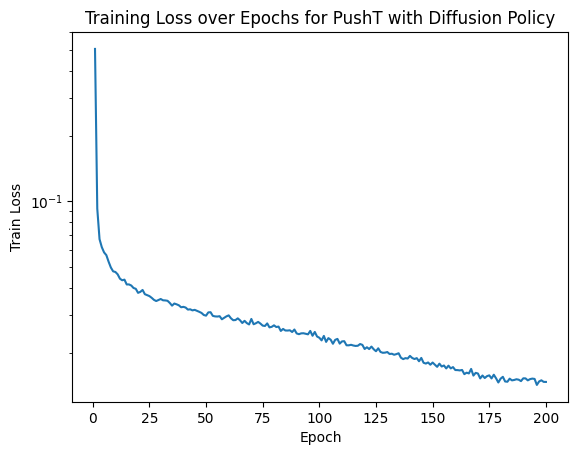

In [33]:
plt.plot(np.arange(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss over Epochs for PushT with Diffusion Policy")
plt.yscale("log")
plt.show()



In [ ]:
# torch.save(model.state_dict(), f"data/diffusion_policy_unet_{time.strftime('%Y-%m-%d_%H-%M-%S')}.pth")

In [38]:
@torch.no_grad()

def sample(model, noise_scheduler: Union[DDPMScheduler, DDIMScheduler], device, stats, obs_horizon=2,
           pred_horizon=16, action_horizon=8, save_path=None, n_inference_steps=100, n_iterations=1):
    model.eval()
    model = model.to(device)
    torch.manual_seed(0)
    np.random.seed(0)

    env = PushTEnv()
    max_steps = 200


    imgs = []

    max_rewards = []

    for i in range(n_iterations):
        env.seed(10000+i)
        obs, info = env.reset()
        imgs.append(env.render(mode='rgb_array'))
        obs_deque = collections.deque([obs]*obs_horizon, maxlen=obs_horizon)
        step_idx = 0

        done = False
        rewards = []
        with tqdm(range(max_steps), desc="Sampling") as pbar:
            while not done:
                obs_array = np.array(obs_deque)
                obs_normalized = normalize_data(obs_array, stats['obs'])
                obs_cond = torch.from_numpy(obs_normalized).float().to(device)

                with torch.no_grad():
                    obs_cond = obs_cond.unsqueeze(0).flatten(start_dim=1)

                    prev_sample = torch.randn((1, pred_horizon, model.im_channels), device=device)

                    noise_scheduler.set_timesteps(n_inference_steps)

                    for k in noise_scheduler.timesteps:
                        t = torch.full((1,), k, device=device, dtype=torch.long)
                        noise_pred = model(prev_sample, t, obs_cond)
                        prev_sample = noise_scheduler.step(noise_pred.cpu(), t.cpu(), prev_sample.cpu()).prev_sample.to(device)

                    actions = unnormalize_data(prev_sample.squeeze(0).cpu().numpy(), stats['action'])

                    start = obs_horizon - 1
                    end = start + action_horizon
                    action_to_take = actions[start:end]

                    for action in action_to_take:
                        obs, reward, terminated, truncated, info = env.step(action)
                        obs_deque.append(obs)
                        imgs.append(env.render(mode='rgb_array'))
                        step_idx += 1
                        pbar.update(1)
                        pbar.set_postfix({"reward": reward})
                        rewards.append(reward)
                        if terminated or truncated:
                            done = True
                            break
                        if step_idx >= max_steps:
                            done = True
                            break

        print('Score: ', max(rewards))
        max_rewards.append(max(rewards))

    if save_path is not None:
        from IPython.display import Video, display
        vwrite(save_path, imgs)
        display(Video(save_path, embed=True, width=256, height=256))

    return max_rewards

In [ ]:
model = UNet(im_channels=2, obs_cond_dim=obs_cond_dim).to(device)
path = "data/diffusion_policy_unet_1000_steps_2026-03-30_19-36-53.pth"
model.load_state_dict(torch.load(path, map_location=device))
n_diffusion_iters = 1000
noise_scheduler = DDIMScheduler(num_train_timesteps=n_diffusion_iters, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
n_inference_steps = 50
path = f"results/diffusion_policy_{n_inference_steps}i_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
# path = None
max_rewards = sample(model, noise_scheduler, device, stats=stats, save_path=path, n_inference_steps=n_inference_steps, n_iterations=5)

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9838377965069828


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9822167368629448


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9408802281340188


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9732865208553196


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.9850941143029491


In [ ]:
n_inference_steps_list = [1, 10, 50]

max_rewards_dict = {k: [] for k in n_inference_steps_list}

average_time_dict = {k: [] for k in n_inference_steps_list}
n_iterations = 10

for n_inference_steps in n_inference_steps_list:
    model = UNet(im_channels=2, obs_cond_dim=obs_cond_dim).to(device)
    path = "data/diffusion_policy_unet_1000_steps_2026-03-30_19-36-53.pth"
    model.load_state_dict(torch.load(path, map_location=device))
    n_diffusion_iters = 1000
    noise_scheduler = DDIMScheduler(num_train_timesteps=n_diffusion_iters, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
    path = f"results/diffusion_policy_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
    path = None
    start_time = time.time()
    max_rewards = sample(model, noise_scheduler, device, stats=stats, save_path=path, n_inference_steps=n_inference_steps, n_iterations=n_iterations)
    delta_t = time.time() - start_time
    max_rewards_dict[n_inference_steps] = max_rewards
    average_time_dict[n_inference_steps] = delta_t / n_iterations

/tmp/ipykernel_1589106/546355413.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(max_rewards_dict.values(), labels=max_rewards_dict.keys())


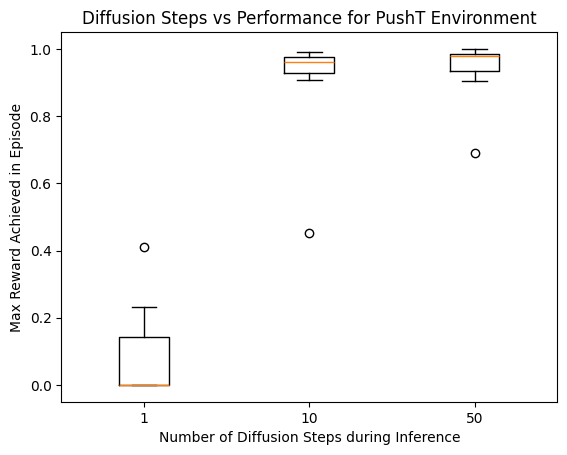

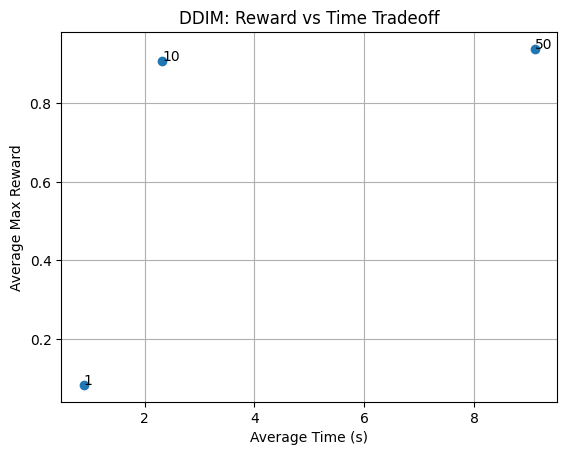

In [17]:
plt.boxplot(max_rewards_dict.values(), labels=max_rewards_dict.keys())
plt.xlabel("Number of Diffusion Steps during Inference")
plt.ylabel("Max Reward Achieved in Episode")
plt.title("Diffusion Steps vs Performance for PushT Environment")
plt.show()

avg_rewards = {k: np.mean(v) for k, v in max_rewards_dict.items()}
avg_times   = {k: np.mean(v) for k, v in average_time_dict.items()}

steps = sorted(avg_rewards.keys())
times = [avg_times[k] for k in steps]
rewards = [avg_rewards[k] for k in steps]

plt.figure()
plt.scatter(times, rewards)

# Label each point with number of inference steps
for i, step in enumerate(steps):
    plt.annotate(str(step), (times[i], rewards[i]))

plt.xlabel("Average Time (s)")
plt.ylabel("Average Max Reward")
plt.title("DDIM: Reward vs Time Tradeoff")
plt.grid(True)
plt.show()

In [40]:
class MLPDiffusionPolicy(nn.Module):
    def __init__(self, im_channels, obs_cond_dim, hidden_dim=256, n_layers=4):
        super().__init__()
        layers = []
        layers.append(nn.Linear(obs_cond_dim, hidden_dim))
        layers.append(nn.Mish())
        for _ in range(n_layers-1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Mish())
        layers.append(nn.Linear(hidden_dim, im_channels))

        self.model = nn.Sequential(*layers)

    def forward(self, obs_cond):
        out = self.model(obs_cond)
        return out

In [68]:
def train_epochs_mlp(model, train_dataloader, test_dataloader, optimizer, ema, lr_scheduler, device, num_epochs):
    model.train()
    pbar_global = tqdm(range(num_epochs), desc="Epoch", leave=True)
    train_losses = []
    test_losses = []
    for epoch in pbar_global:
        total_loss = 0
        test_loss = 0
        pbar_batch = tqdm(train_dataloader, desc="Batch", leave=False)
        for batch in pbar_batch:
            actions = batch['action'].to(device)
            obs = batch['obs'].to(device)
            obs_cond = obs.reshape(obs.shape[0], -1)
            b, *_ = actions.shape

            optimizer.zero_grad()
            action_pred = model(obs_cond)

            loss = F.mse_loss(action_pred, actions[:,0,:])
            loss.backward()
            optimizer.step()

            lr_scheduler.step()
            ema.step(model.parameters())

            total_loss += loss.item() * b
            pbar_batch.set_postfix({"loss": loss.item()})
        with torch.no_grad():
            test_loss = 0
            for batch in test_dataloader:
                actions = batch['action'].to(device)
                obs = batch['obs'].to(device)
                obs_cond = obs.reshape(obs.shape[0], -1)

                action_pred = model(obs_cond)

                loss = F.mse_loss(action_pred, actions[:,0,:])
                test_loss += loss.item() * actions.shape[0]
        loss = total_loss / len(train_dataloader.dataset)
        test_loss = test_loss / len(test_dataloader.dataset)
        pbar_global.set_postfix({"loss": loss, "test_loss": test_loss})
        train_losses.append(loss)
        test_losses.append(test_loss)

    ema.copy_to(model.parameters())
    return train_losses, test_losses

In [81]:
num_epochs = 200
action_dim = 2
obs_dim = 5
obs_horizon = 2
obs_cond_dim = obs_dim*obs_horizon
mlp_model = MLPDiffusionPolicy(im_channels=action_dim, obs_cond_dim=obs_cond_dim, hidden_dim=512, n_layers=4).to(device)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-4)
lr_scheduler = get_scheduler(
    name='cosine',
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(dataloader) * num_epochs
)
ema = EMAModel(mlp_model.parameters(), power=0.75, use_ema_warmup=True)
train_set, test_set = torch.utils.data.random_split(dataset, [0.8, 0.2])
mlp_train_dataloaders = torch.utils.data.DataLoader(
    train_set,
    batch_size=256,
    num_workers=1,
    shuffle=True,
    pin_memory=True,
    persistent_workers=True
)
mlp_test_dataloaders = torch.utils.data.DataLoader(
    test_set,
    batch_size=256,
    num_workers=1,
    shuffle=True,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
train_losses, test_losses = train_epochs_mlp(mlp_model, mlp_train_dataloaders, mlp_test_dataloaders, optimizer, ema, lr_scheduler, device, num_epochs)

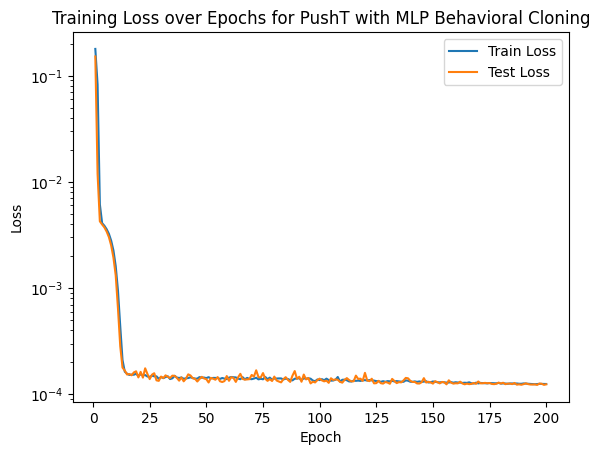

In [84]:
plt.plot(np.arange(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(np.arange(1, len(test_losses) + 1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs for PushT with MLP Behavioral Cloning")
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:
# torch.save(mlp_model.state_dict(), f"data/mlp_bc_policy_{time.strftime('%Y-%m-%d_%H-%M-%S')}.pth")

In [42]:
@torch.no_grad()

def sample_mlp(model, device, stats, obs_horizon=2, save_path=None, n_iterations=1):
    model.eval()
    model = model.to(device)
    torch.manual_seed(0)
    np.random.seed(0)

    env = PushTEnv()
    max_steps = 200
    max_rewards = []
    imgs = []

    for i in range(n_iterations):
        env.seed(10000 + i)
        obs, info = env.reset()
        obs_deque = collections.deque([obs]*obs_horizon, maxlen=obs_horizon)

        imgs.append(env.render(mode='rgb_array'))
        step_idx = 0

        done = False
        rewards = []

        with tqdm(range(max_steps), desc="Sampling") as pbar:
            while not done:
                obs_current = np.array(obs_deque)
                obs_normalized = normalize_data(obs_current, stats['obs'])
                obs_cond = torch.from_numpy(obs_normalized).float().to(device)

                with torch.no_grad():
                    obs_cond = obs_cond.unsqueeze(0).flatten(start_dim=1)

                    action = model(obs_cond)

                    action = unnormalize_data(action.squeeze(0).cpu().numpy(), stats['action'])

                    obs, reward, terminated, truncated, info = env.step(action)
                    obs_deque.append(obs)
                    imgs.append(env.render(mode='rgb_array'))
                    step_idx += 1
                    pbar.set_postfix({"reward": reward})
                    rewards.append(reward)
                    if terminated or truncated:
                        done = True
                        break
                    if step_idx >= max_steps:
                        done = True
                        break

        print('Score: ', max(rewards))
        max_rewards.append(max(rewards))
    if save_path is not None:
        from IPython.display import Video, display
        vwrite(save_path, imgs)
        display(Video(save_path, embed=True, width=256, height=256))

    return max_rewards

In [ ]:
save_path = f"results/mlp_policy_{time.strftime('%Y-%m-%d_%H-%M-%S')}.mp4"
# save_path = None
mlp_model = MLPDiffusionPolicy(im_channels=2, obs_cond_dim=obs_dim*obs_horizon, hidden_dim=512, n_layers=4).to(device)
load_path = "data/mlp_bc_policy_2026-04-01_13-12-09.pth"
mlp_model.load_state_dict(torch.load(load_path, map_location=device))
max_rewards = sample_mlp(mlp_model, device, stats=stats, save_path=save_path, n_iterations=5)

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.0


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.05620344689165952


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.03353553959225146


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.4105456394814651


Sampling:   0%|          | 0/200 [00:00<?, ?it/s]

Score:  0.0016897702131731228


In [ ]:
n_inference_steps_list = [1, 10, 50, 100, 500, 1000, "MLP"]

max_rewards_dict = {k: [] for k in n_inference_steps_list}

average_time_dict = {k: [] for k in n_inference_steps_list}
n_iterations = 10

for n_inference_steps in n_inference_steps_list:
    save_path = None
    if n_inference_steps == "MLP":
        mlp_model = MLPDiffusionPolicy(im_channels=2, obs_cond_dim=obs_cond_dim, hidden_dim=512, n_layers=4).to(device)
        load_path = "data/mlp_bc_policy_2026-04-01_13-12-09.pth"
        mlp_model.load_state_dict(torch.load(load_path, map_location=device))
        start_time = time.time()
        max_rewards = sample_mlp(mlp_model, device, stats=stats, save_path=save_path, n_iterations=n_iterations)
        delta_t = time.time() - start_time
    else:
        model = UNet(im_channels=2, obs_cond_dim=obs_cond_dim).to(device)
        load_path = "data/diffusion_policy_unet_1000_steps_2026-03-30_19-36-53.pth"
        model.load_state_dict(torch.load(load_path, map_location=device))
        n_diffusion_iters = 1000
        noise_scheduler = DDIMScheduler(num_train_timesteps=n_diffusion_iters, beta_start=1e-4, beta_end=0.02, beta_schedule="squaredcos_cap_v2", clip_sample=True, prediction_type="epsilon")
        start_time = time.time()
        max_rewards = sample(model, noise_scheduler, device, stats=stats, save_path=save_path, n_inference_steps=n_inference_steps, n_iterations=n_iterations)
        delta_t = time.time() - start_time
    max_rewards_dict[n_inference_steps] = max_rewards
    average_time_dict[n_inference_steps] = delta_t / n_iterations

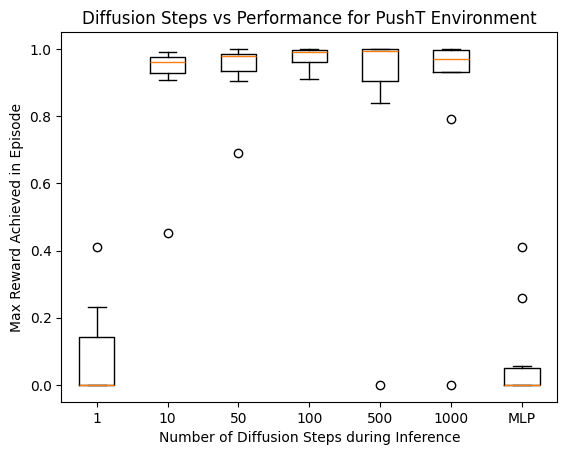

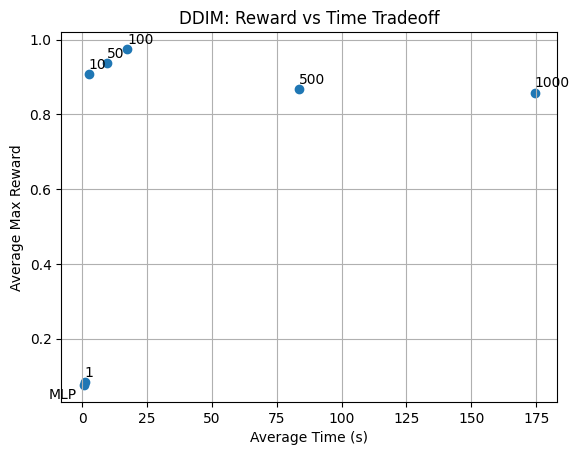

In [ ]:
tradeoff_results = pickle.load(open("data/tradeoff_results_2026-04-01_15-28-36.pkl", "rb"))
max_rewards_dict = tradeoff_results['max_rewards']
average_time_dict = tradeoff_results['average_time']
plt.boxplot(max_rewards_dict.values(), tick_labels=max_rewards_dict.keys())
plt.xlabel("Number of Diffusion Steps during Inference")
plt.ylabel("Max Reward Achieved in Episode")
plt.title("Diffusion Steps vs Performance for PushT Environment")
plt.show()

avg_rewards = {k: np.mean(v) for k, v in max_rewards_dict.items()}
avg_times   = {k: np.mean(v) for k, v in average_time_dict.items()}

steps = avg_rewards.keys()
times = [avg_times[k] for k in steps]
rewards = [avg_rewards[k] for k in steps]

plt.figure()
plt.scatter(times, rewards)

# Label each point with number of inference steps
for i, step in enumerate(steps):
    if step == "MLP":
        label = "MLP"
        plt.annotate(label, (times[i], rewards[i]), xytext=(-25,-10), textcoords='offset points')
    else:
        label = str(step)
        plt.annotate(label, (times[i], rewards[i]), xytext=(0,4), textcoords='offset points')

plt.xlabel("Average Time (s)")
plt.ylabel("Average Max Reward")
plt.title("DDIM: Reward vs Time Tradeoff")
plt.grid(True)
plt.show()